# Лабораторная работа 6

## Ансамбли моделей машинного обучения. Часть 2.
### Цель лабораторной работы: изучение ансамблей моделей машинного обучения.

# Датасет:
Текстовое описание набора данных
Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx

Каждый файл содержит следующие колонки:

Date дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
Time время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
CO(GT) концентрация СО mg/m^3
PT08.S1(CO) концентрация СО mg/m^3 усредненная за час
NMHC(GT) максимальная концентрация паров гидрокарбонатов усредненная за час microg/m^3
C6H6(GT) максимальная концентрация паров бензина усредненная за час microg/m^3
PT08.S2(NMHC) концентрация паров гидрокарбонатов усредненная за час microg/m^3
NOx(GT) максимальная концентрация оксидов азота усредненная за час microg/m^3
PT08.S3(NOx) концентрация оксидов азота усредненная за час microg/m^3
NO2(GT) максимальная концентрация двуокиси азота усредненная за час microg/m^3
PT08.S4(NO2) концентрация двуокиси азота усредненная за час microg/m^3
PT08.S5(O3) концентрация озона усредненная за час microg/m^3
T температура в градусах Цельсия
RH относительная влажность в %.
AH абсолютная влажность в %.
Category категория качества воздуха - Good/Bad


In [1]:
import gmdh
#from keras.models import Sequential
#from keras.layers import Dense
#from keras.layers import LSTM
from scipy.stats import mode
from time import time
import os
import random
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from io import StringIO 
from IPython.display import Image
import graphviz 
import pydotplus
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import display, HTML
from itertools import chain
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";")
data = data.drop(columns=['Unnamed: 16'])

In [4]:
# Первые 5 строк датасета
data.head()

,Date,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
0,10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
1,10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
2,10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
3,10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
4,10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


In [5]:
#Удаление строк с пропусками
data = data.dropna(axis=0, how='any')
data.shape

(827, 16)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        827 non-null    object 
 1   Time        827 non-null    object 
 2   COGT        827 non-null    float64
 3   PT08S1CO    827 non-null    float64
 4   NMHCGT      827 non-null    float64
 5   C6H6GT      827 non-null    float64
 6   PT08S2NMHC  827 non-null    float64
 7   NOxGT       827 non-null    float64
 8   PT08S3NOx   827 non-null    float64
 9   NO2GT       827 non-null    float64
 10  PT08S4NO2   827 non-null    float64
 11  PT08S5O3    827 non-null    int64  
 12  T           827 non-null    float64
 13  RH          827 non-null    float64
 14  AH          827 non-null    float64
 15  Category    827 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory usage: 109.8+ KB


In [7]:
data.describe()

,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,2.353567,1207.879081,231.025393,10.771100,966.116082,143.501814,963.297461,100.259976,1600.620314,1045.812576,15.601451,49.050181,0.831853
std,1.409496,241.816997,208.461912,7.418134,266.424557,81.829717,265.914168,31.493823,302.291793,400.134662,4.825304,15.266746,0.178506
min,0.300000,753.000000,7.000000,0.500000,448.000000,12.000000,461.000000,19.000000,955.000000,263.000000,6.300000,14.900000,0.402300
25%,1.300000,1017.000000,77.000000,4.800000,754.000000,81.000000,769.000000,78.500000,1369.500000,760.000000,11.900000,36.700000,0.718950
50%,2.000000,1172.000000,157.000000,9.100000,944.000000,128.000000,920.000000,99.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700
75%,3.100000,1380.000000,318.500000,14.800000,1142.500000,187.000000,1131.000000,122.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500
max,8.100000,2040.000000,1189.000000,39.200000,1754.000000,478.000000,1935.000000,196.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200


In [8]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(5, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels)
    ax1.set_title(str_header)
    for a,b in zip(pos, array_metric):
        plt.text(0.2, a-0.1, str(round(b,3)), color='white')
    plt.show()

In [9]:
from heamy.estimator import Regressor, Classifier
from heamy.pipeline import ModelsPipeline
from heamy.dataset import Dataset

In [10]:
# Качество отдельных моделей
def val_mae(model):
    model.fit(X_train, Y_train.ravel())
    y_pred = model.predict(X_test)
    result = mean_absolute_error(Y_test, y_pred)
    print(model)
    print('MAE={}'.format(result))

In [11]:
#Преобразование категориальных признаков в числовые
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['Category']]
oe = OrdinalEncoder()
enc_oe = oe.fit_transform(data_oe)

# Стекинг 

In [12]:
# Используем данные из регрессии Лаб 4
X=data['COGT'].to_numpy().reshape(-1, 1)
Y=data['C6H6GT'].to_numpy().reshape(-1, 1)

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size = 0.3, random_state= 1)

In [14]:
# Точность на отдельных моделях
for model in [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(n_estimators=50)
]:
    val_mae(model)
    print('==========================')
    print()


LinearRegression()
MAE=1.1951824983671004

DecisionTreeRegressor()
MAE=1.2578608540416605

RandomForestRegressor(n_estimators=50)
MAE=1.2276420619428337



In [15]:
# набор данных
dataset = Dataset(X_train, Y_train.ravel(), X_test)

# модели первого уровня
model_tree = Regressor(dataset=dataset, estimator=DecisionTreeRegressor, name='tree')
model_lr = Regressor(dataset=dataset, estimator=LinearRegression,name='lr')
model_rf = Regressor(dataset=dataset, estimator=RandomForestRegressor, parameters={'n_estimators': 50},name='rf')


In [16]:
# Эксперимент 1
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: линейная регрессия

pipeline = ModelsPipeline(model_tree, model_lr)
stack_ds = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)


Metric: mean_absolute_error
Folds accuracy: [1.4214712014540671, 1.076758801648926, 1.3204326728955063, 1.4512841199772413, 1.0990105594090327, 1.2975832066646178, 1.218915896827973, 1.3955374838179084, 1.1451352904449914, 1.4960190628395487]
Mean accuracy: 1.2922148295979812
Standard Deviation: 0.1434577867191578
Variance: 0.020580136570359363


In [17]:
# Эксперимент 2
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: случайный лес

stacker = Regressor(dataset=stack_ds, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [1.1474356869184426, 1.0670476737821577, 1.3313499384236442, 1.3503808970244315, 1.174334171766931, 1.347604611384783, 1.2825549876847264, 1.3950090336866225, 0.9856120490620501, 1.6108980519480505]
Mean accuracy: 1.2692227101681839
Standard Deviation: 0.1716035606839173
Variance: 0.029447782039398886


In [18]:
# Эксперимент 3
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: линейная регрессия
pipeline = ModelsPipeline(model_tree, model_lr, model_rf)
stack_ds3 = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds3, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)


Metric: mean_absolute_error
Folds accuracy: [1.4179698763391495, 1.081130348288453, 1.3159456272654464, 1.4544875707053764, 1.0967959680837696, 1.2900235665463067, 1.2148320575813287, 1.4036091865226241, 1.1581011114758288, 1.4938014185852975]
Mean accuracy: 1.292669673139358
Standard Deviation: 0.1422948649620056
Variance: 0.02024782859455541


In [19]:
# Эксперимент 4
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: случайный лес
# Результат хуже чем в эксперименте 3
stacker = Regressor(dataset=stack_ds3, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [1.2188451012588926, 1.0458742626626263, 1.3445578817733972, 1.41345074700204, 1.1584418856048175, 1.4648157772304313, 1.3198462643678144, 1.3944498015873024, 1.0055020885547212, 1.5456415552770828]
Mean accuracy: 1.2911425365319125
Standard Deviation: 0.16994831894682433
Variance: 0.028882431112851527


In [20]:
# Результаты
array_labels = ['LR','TREE', 'RF', 'TREE+LR=>LR', 
                'TREE+LR=>RF', 'TREE+LR+RF=>LR', 'TREE+LR+RF=>RF']
array_mae = [3.7507121808389168, 2.942156862745098, 2.263039215686275, 
             2.6766504031924305, 2.6775473780487804, 2.2998386142710823, 
             2.406510426829268]

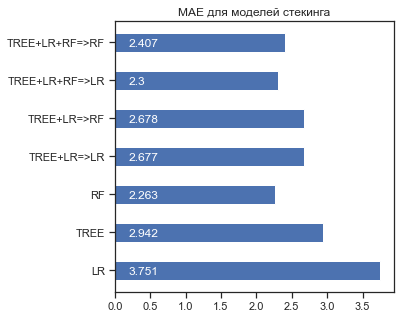

In [21]:
# Визуализация результатов
vis_models_quality(array_mae, array_labels, 'MAE для моделей стекинга')

# Обучение нейронной сети

In [22]:
# данные для обучения
X = data[['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']]
y = enc_oe[:, 0]
X_train, X_test, Y_train, Y_test = train_test_split(X, y , test_size = 0.3, random_state= 1)


In [23]:
mlp = MLPClassifier()
mlp.fit(X_train, Y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [24]:
accuracy_score(Y_test, mlp.predict(X_test)) # Test Accuracy

0.8835341365461847

In [25]:
i = 0
df = pd.DataFrame(columns = ['alpha','max_iter','train_acc','test_acc','train_time'])
for a in [0.00001,0.0001,0.001,0.01, 0.1, 1, 10]:
    for mi in [10,100,200,500,1000,2000]:
        st = time()
        mlp = MLPClassifier(alpha=a, max_iter=mi)
        mlp.fit(X_train, Y_train)
        end = time() - st
        
        acc_tr = accuracy_score(Y_train, mlp.predict(X_train)) # Train Accuracy
        acc = accuracy_score(Y_test, mlp.predict(X_test)) # Test Accuracy
        df.loc[i] = [a,mi,acc_tr,acc,end]
        i=i+1

In [26]:
df

,alpha,max_iter,train_acc,test_acc,train_time
0,0.00001,10.0,0.579585,0.550201,0.102185
1,0.00001,100.0,0.859862,0.875502,0.353136
2,0.00001,200.0,0.875433,0.867470,0.700394
3,0.00001,500.0,0.913495,0.915663,1.519724
4,0.00001,1000.0,0.913495,0.915663,2.125585
5,0.00001,2000.0,0.916955,0.911647,1.600431
6,0.00010,10.0,0.560554,0.546185,0.034823
7,0.00010,100.0,0.852941,0.847390,0.308606
8,0.00010,200.0,0.885813,0.883534,0.627301
9,0.00010,500.0,0.908304,0.911647,1.246140


### Best result Model 23 	0.01000 	2000.0 	0.953287 	0.955823 	2.311226
Alpha = 0.01 Iterations = 2000

In [27]:
acc = []
acc_tr = []
timelog = []
for l in [10,20,50,100,200,500,1000]:
    t = time()
    mlp = MLPClassifier(alpha=0.01, max_iter=2000, hidden_layer_sizes=(l,))
    mlp.fit(X_train, Y_train)
    endt = time() - t
        
    a_tr = accuracy_score(Y_train, mlp.predict(X_train)) # Train Accuracy
    a = accuracy_score(Y_test, mlp.predict(X_test)) # Test Accuracy

    acc_tr.append(a_tr)
    acc.append(a)
    timelog.append(endt)

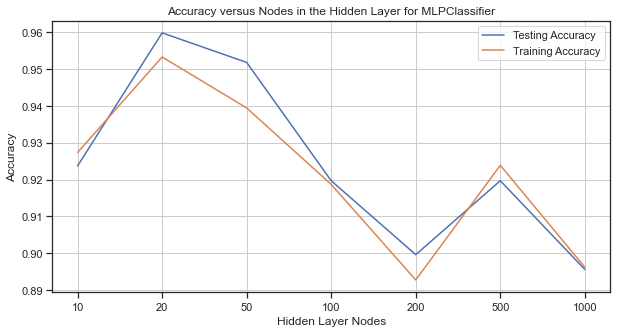

In [28]:
l = [10,20,50,100,200,500,1000]
N = len(l)
l2 = np.arange(N)
plt.subplots(figsize=(10, 5))
plt.plot(l2, acc, label="Testing Accuracy")
plt.plot(l2, acc_tr, label="Training Accuracy")
plt.xticks(l2,l)
plt.grid(True)
plt.xlabel("Hidden Layer Nodes")
plt.ylabel("Accuracy")
plt.legend()
plt.title('Accuracy versus Nodes in the Hidden Layer for MLPClassifier', fontsize=12)
plt.show()

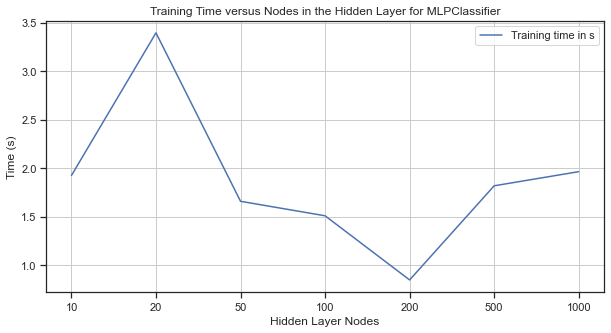

In [29]:
l = [10,20,50,100,200,500,1000]
N = len(l)
l2 = np.arange(N)
plt.subplots(figsize=(10, 5))
plt.plot(l2, timelog, label="Training time in s")
plt.xticks(l2,l)
plt.grid(True)
plt.xlabel("Hidden Layer Nodes")
plt.ylabel("Time (s)")
plt.legend()
plt.title('Training Time versus Nodes in the Hidden Layer for MLPClassifier', fontsize=12)
plt.show()

### Final model parameters for highest test accuracy:
* Alpha = 0.01
* Max Iterations = 2000
* Hidden Layer Nodes = 20

# GMDH Regression

In [30]:
def adfuller_test(ts):
    res = adfuller(ts)
    print('Dickey-Fuller test\n')
    print(f'statistic: {res[0]}')
    print(f'p-value: {res[1]}')
    print(f'\ncritical values')
    print(f'10%: {res[4]["10%"]}')
    print(f'5%: {res[4]["5%"]}')
    print(f'1%: {res[4]["1%"]}')

def print_metrics(y_test, y_pred, squared=False):
    print(f"R^2: {r2_score(y_test, y_pred)}")
    crit_name = "MSE" if squared else "RMSE"
    print(f"{crit_name}: {mean_squared_error(y_test, y_pred)}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")

def get_predicted(model, lags):
  if lags > 1:
    return scaler.inverse_transform(model.predict(x_test[0], lags=lags).reshape(-1, 1))
  else:
    return scaler.inverse_transform(model.predict(x_test).reshape(-1, 1))

def show_all_plot(y_pred):
  plt.figure(figsize=(16, 4))
  if needDiff:
    sns.lineplot(y=data.diff().dropna(), x=range(data.shape[0]-1), label='real')
  else:
    sns.lineplot(y=data, x=range(data.shape[0]), label='real')
  sns.lineplot(y=y_pred.flatten(), x=range(y_train.shape[0]+lags, y_train.shape[0] + len(y_pred) + lags), label='pred');

def show_part_plot(y_pred, nFirstPreds=365):
  plt.figure(figsize=(16, 4))
  sns.lineplot(y=scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()[:nFirstPreds], x=range(nFirstPreds), label='real')
  sns.lineplot(y=y_pred.flatten()[:nFirstPreds], x=range(nFirstPreds), label='pred')

def show_metric_for(y_pred, n=365):
  print_metrics(scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()[:n], y_pred[:n])


In [31]:
# Используем данные из регрессии Лаб 4
X=data['COGT']
Y=data['C6H6GT']

In [32]:
x_train, x_test, y_train, y_test = gmdh.split_data(X, Y, test_size=0.9)
scaler = MinMaxScaler().fit(x_train)
a_x_train = scaler.transform(x_train)
a_x_test = scaler.transform(x_test)
print("train elements:", x_train.shape[0], "\ntest elements:", x_test.shape[0])

train elements: 83 
test elements: 744


In [33]:
combi_model = gmdh.Combi()
combi_model.fit(a_x_train, y_train, verbose=1, n_jobs=-1, test_size=0.24, limit=0, 
                       criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY))
y_pred_combi = combi_model.predict(a_x_test)
print_metrics(y_test, y_pred_combi)


LEVEL 1  [=========================] 100% :00s] (1 combinations) error=17.936689
R^2: 0.8994250464587362
RMSE: 5.705043710918737
MAE: 1.7403567501502641


In [34]:
multi_model = gmdh.Multi()
multi_model.fit(a_x_train, y_train, verbose=1, n_jobs=-1, test_size=0.24, limit=0, k_best=5, 
                       criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY))
y_pred_multi = multi_model.predict(a_x_test)
print_metrics(y_test, y_pred_multi)


LEVEL 1  [=========================] 100% :00s] (1 combinations) error=17.936689
R^2: 0.8994250464587362
RMSE: 5.705043710918737
MAE: 1.7403567501502641
